# Evaluate harness results

Load a long-format `results.csv` from an `evaluate_harness` run, print per-metric
summaries, and plot histograms. Figures can be saved as high-DPI PDFs.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

In [2]:
DEFAULT_DPI = 300

plt.rcParams.update(
    {
        "figure.dpi": DEFAULT_DPI,
        "savefig.dpi": DEFAULT_DPI,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

In [3]:
def load_harness_results(csv_path: str | Path) -> pd.DataFrame:
    """Load and validate an evaluate_harness results CSV."""
    path = Path(csv_path).expanduser().resolve()
    if not path.is_file():
        raise FileNotFoundError(path)

    df = pd.read_csv(path)
    required = {"sample_idx", "metric", "value"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns {sorted(missing)} in {path}")

    df["value"] = pd.to_numeric(df["value"], errors="raise")
    return df


def summarize_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """Return per-metric count, mean, std, median, min, and max."""
    summary = (
        df.groupby("metric", sort=True)["value"]
        .agg(["count", "mean", "std", "median", "min", "max"])
        .reset_index()
    )
    return summary


def print_metric_averages(df: pd.DataFrame) -> pd.DataFrame:
    """Print and return per-metric summary statistics."""
    summary = summarize_metrics(df)
    display(summary)
    return summary


def _metric_values(df: pd.DataFrame, metric: str) -> np.ndarray:
    values = df.loc[df["metric"] == metric, "value"].to_numpy(dtype=float)
    if values.size == 0:
        raise KeyError(f"Metric {metric!r} not found. Available: {sorted(df['metric'].unique())}")
    return values


def plot_metric_histogram(
    df: pd.DataFrame,
    metric: str,
    *,
    ax: plt.Axes | None = None,
    bins: int | str = "auto",
    color: str = "#4C72B0",
    show_mean: bool = True,
) -> plt.Axes:
    """Plot a histogram for one metric."""
    values = _metric_values(df, metric)
    created_fig = ax is None
    if created_fig:
        _, ax = plt.subplots(figsize=(5, 3.5))

    ax.hist(values, bins=bins, color=color, edgecolor="white", linewidth=0.6, alpha=0.9)
    ax.set_title(metric)
    ax.set_xlabel("value")
    ax.set_ylabel("count")

    if show_mean:
        mean = float(np.mean(values))
        ax.axvline(mean, color="#E05A4E", linestyle="--", linewidth=1.5, label=f"mean = {mean:.4g}")
        ax.legend(frameon=False)

    if created_fig:
        plt.tight_layout()
    return ax


def plot_all_metric_histograms(
    df: pd.DataFrame,
    *,
    save_dir: str | Path | None = None,
    save_prefix: str = "histogram",
    dpi: int = DEFAULT_DPI,
    bins: int | str = "auto",
    ncols: int = 3,
    show: bool = True,
) -> dict[str, plt.Figure]:
    """Plot histograms for every metric in a grid; optionally save PDFs."""
    metrics = sorted(df["metric"].unique())
    n_metrics = len(metrics)
    nrows = int(np.ceil(n_metrics / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.5 * nrows), squeeze=False)
    axes_flat = axes.ravel()

    for ax, metric in zip(axes_flat, metrics):
        plot_metric_histogram(df, metric, ax=ax, bins=bins)

    for ax in axes_flat[n_metrics:]:
        ax.set_visible(False)

    fig.suptitle("Metric histograms", y=1.02)
    fig.tight_layout()

    figures: dict[str, plt.Figure] = {"all_metrics": fig}

    if save_dir is not None:
        out_dir = Path(save_dir)
        out_dir.mkdir(parents=True, exist_ok=True)

        combined_path = out_dir / f"{save_prefix}_all_metrics.pdf"
        fig.savefig(combined_path, format="pdf", dpi=dpi, bbox_inches="tight")
        print(f"Saved {combined_path}")

        for metric in metrics:
            single_fig, _ = plt.subplots(figsize=(5, 3.5))
            plot_metric_histogram(df, metric, ax=single_fig.gca(), bins=bins)
            single_fig.tight_layout()
            single_path = out_dir / f"{save_prefix}_{metric}.pdf"
            single_fig.savefig(single_path, format="pdf", dpi=dpi, bbox_inches="tight")
            figures[metric] = single_fig
            print(f"Saved {single_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return figures


def evaluate_harness_csv(
    csv_path: str | Path,
    *,
    save_dir: str | Path | None = None,
    save_prefix: str = "histogram",
    dpi: int = DEFAULT_DPI,
    bins: int | str = "auto",
    show: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, plt.Figure]]:
    """Load results, print averages, and plot histograms.

    Returns
    -------
    df : raw long-format results
    summary : per-metric statistics
    figures : mapping of figure name -> matplotlib Figure
    """
    df = load_harness_results(csv_path)

    print(f"Loaded {len(df)} rows from {Path(csv_path).resolve()}")
    if "run_id" in df.columns:
        print(f"run_id: {df['run_id'].iloc[0]}")
    print(f"samples: {df['sample_idx'].nunique()}  metrics: {df['metric'].nunique()}")
    print()

    summary = print_metric_averages(df)
    figures = plot_all_metric_histograms(
        df,
        save_dir=save_dir,
        save_prefix=save_prefix,
        dpi=dpi,
        bins=bins,
        show=show,
    )
    return df, summary, figures

Loaded 256 rows from /home/deniz/rl-mesh-deformation/outputs/evaluate_harness/2026-06-01/21-02-24/results.csv
run_id: 21-02-24
samples: 32  metrics: 8



,metric,count,mean,std,median,min,max
0,chamfer_a2b,32,0.004381,0.004486,0.001955,0.000042,0.014704
1,chamfer_b2a,32,0.009210,0.012614,0.005265,0.000488,0.062422
2,chamfer_sym,32,0.006795,0.007452,0.003937,0.000265,0.033035
3,normal_a2b,32,0.060455,0.087328,0.025793,0.002207,0.446805
4,normal_b2a,32,0.075289,0.101444,0.033005,0.002332,0.363123
5,normal_sym,32,0.067872,0.089899,0.036506,0.002270,0.394237
6,segment_std,32,0.102086,0.032781,0.105105,0.050749,0.161908
7,self_intersection,32,0.656250,1.382130,0.000000,0.000000,6.000000


Saved report/figures/learned/histogram_all_metrics.pdf
Saved report/figures/learned/histogram_chamfer_a2b.pdf
Saved report/figures/learned/histogram_chamfer_b2a.pdf
Saved report/figures/learned/histogram_chamfer_sym.pdf
Saved report/figures/learned/histogram_normal_a2b.pdf
Saved report/figures/learned/histogram_normal_b2a.pdf
Saved report/figures/learned/histogram_normal_sym.pdf
Saved report/figures/learned/histogram_segment_std.pdf
Saved report/figures/learned/histogram_self_intersection.pdf


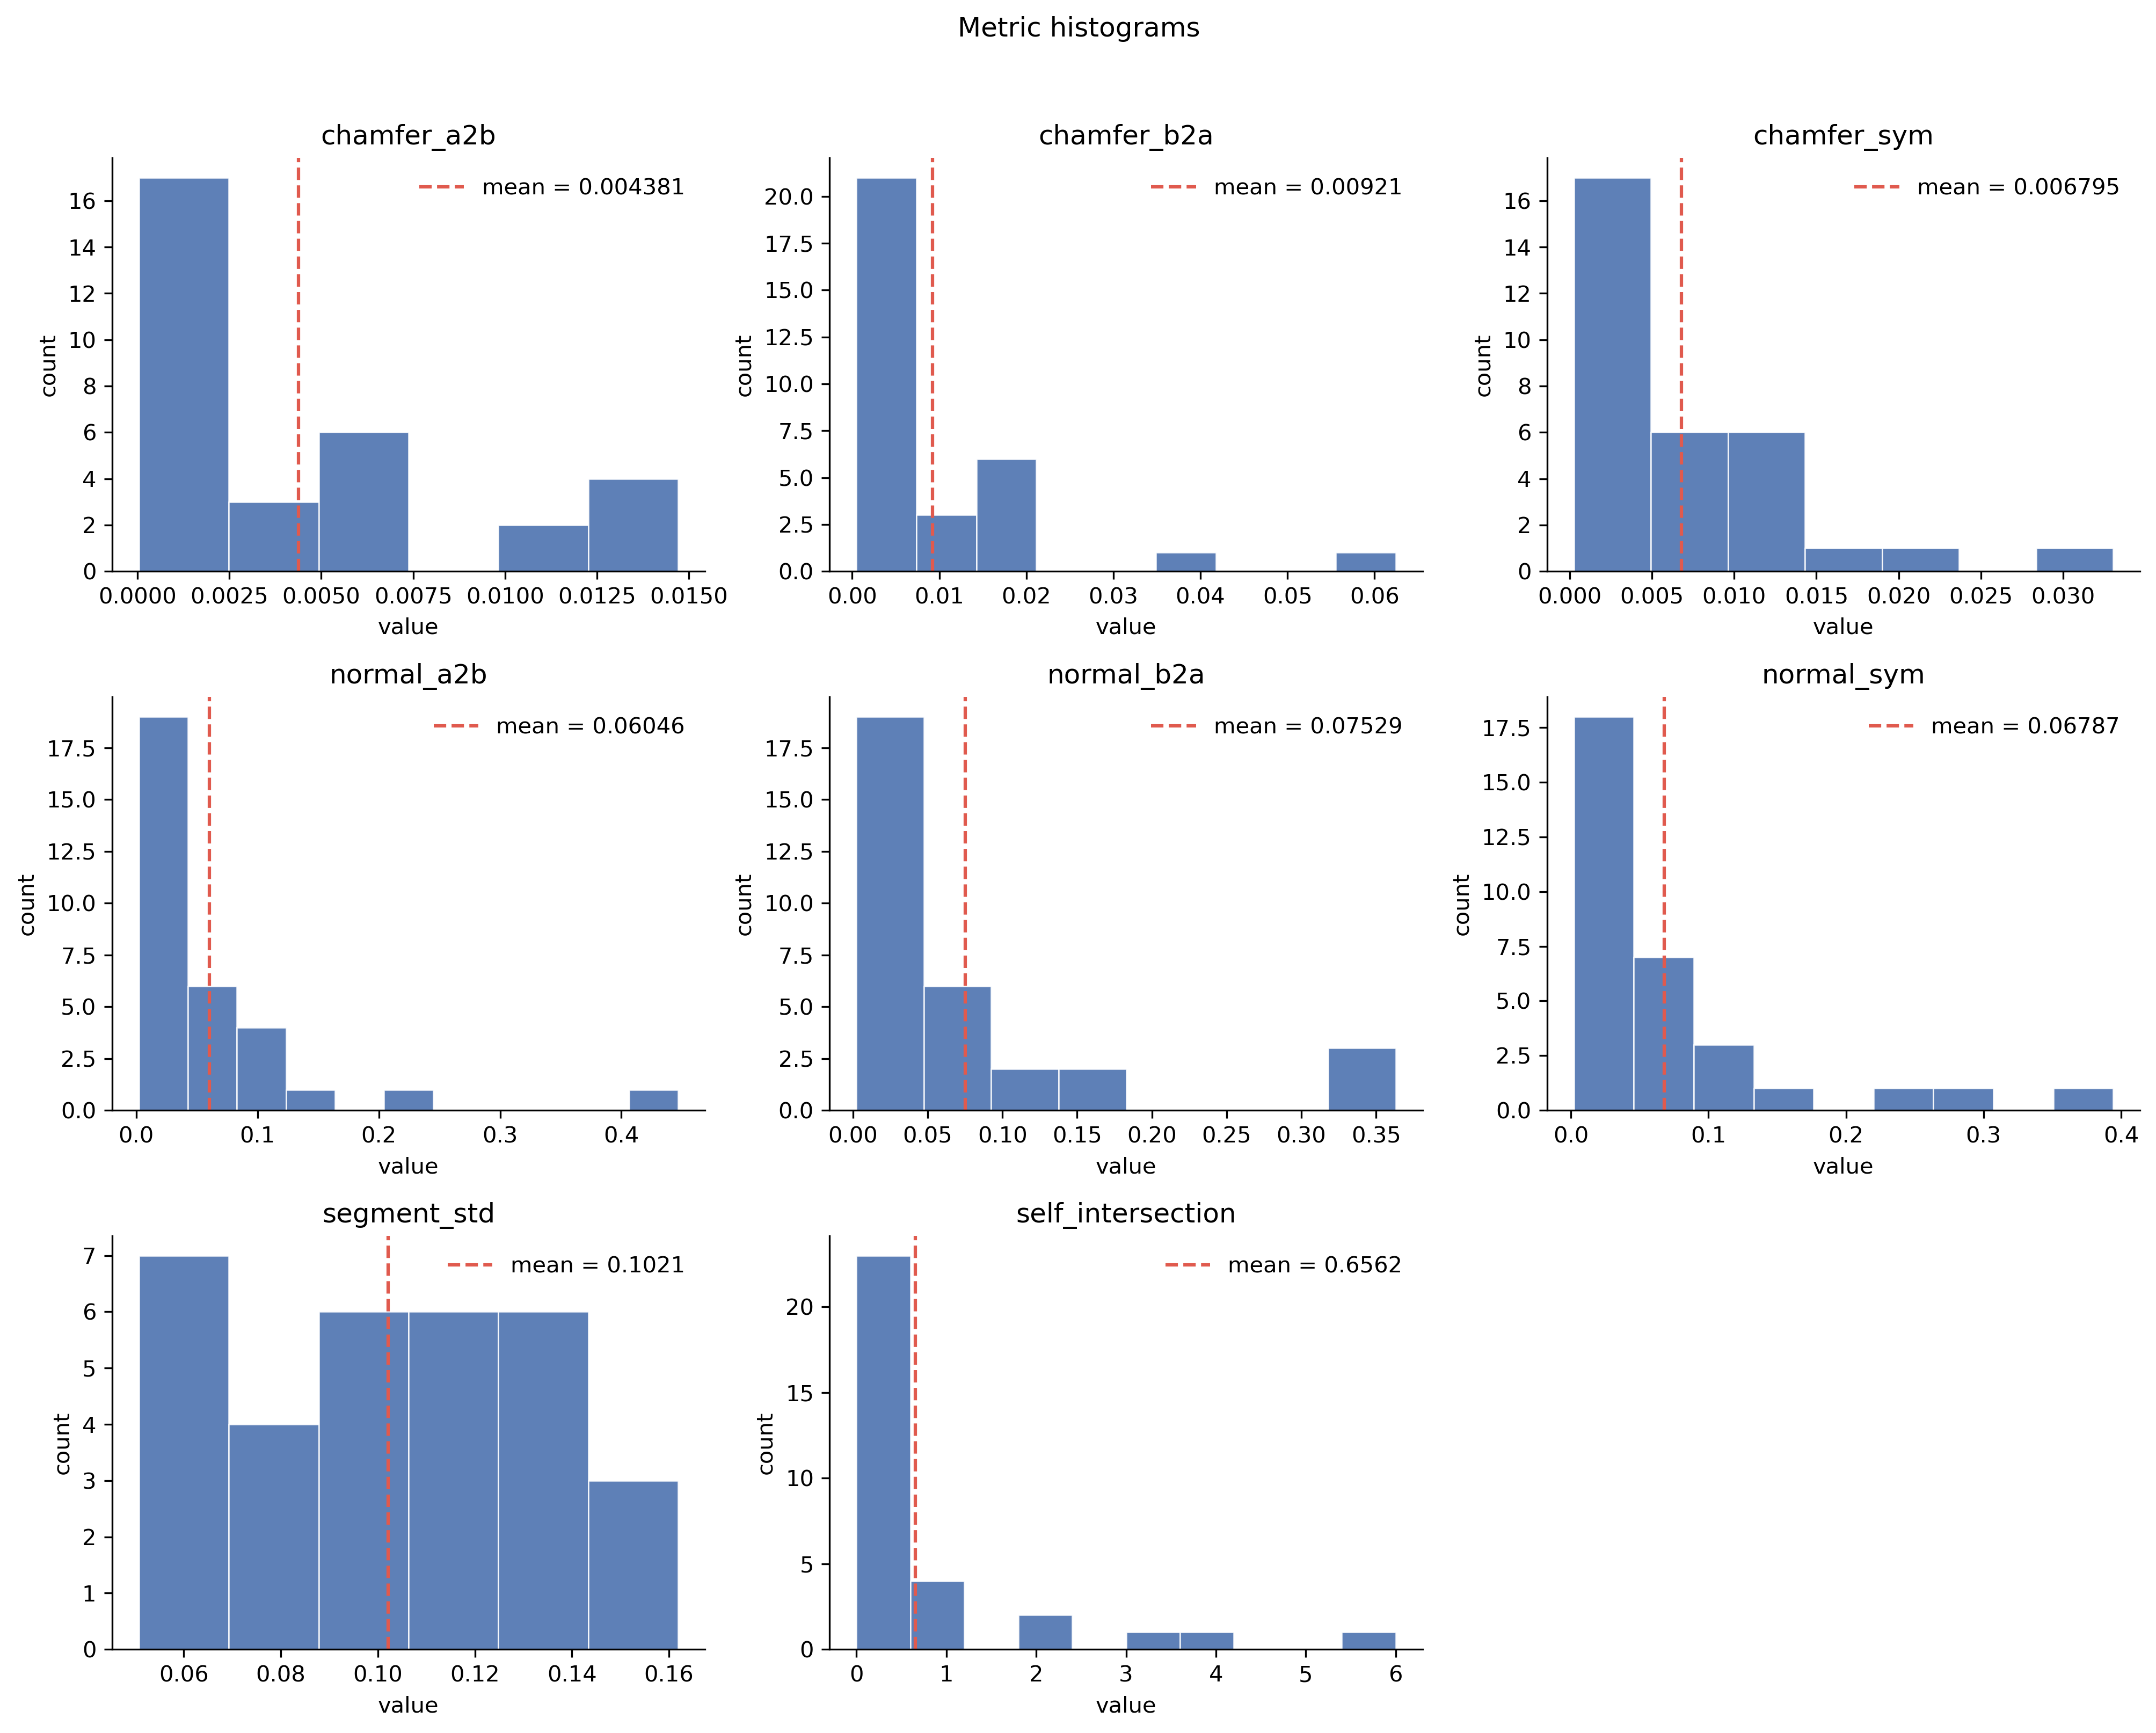

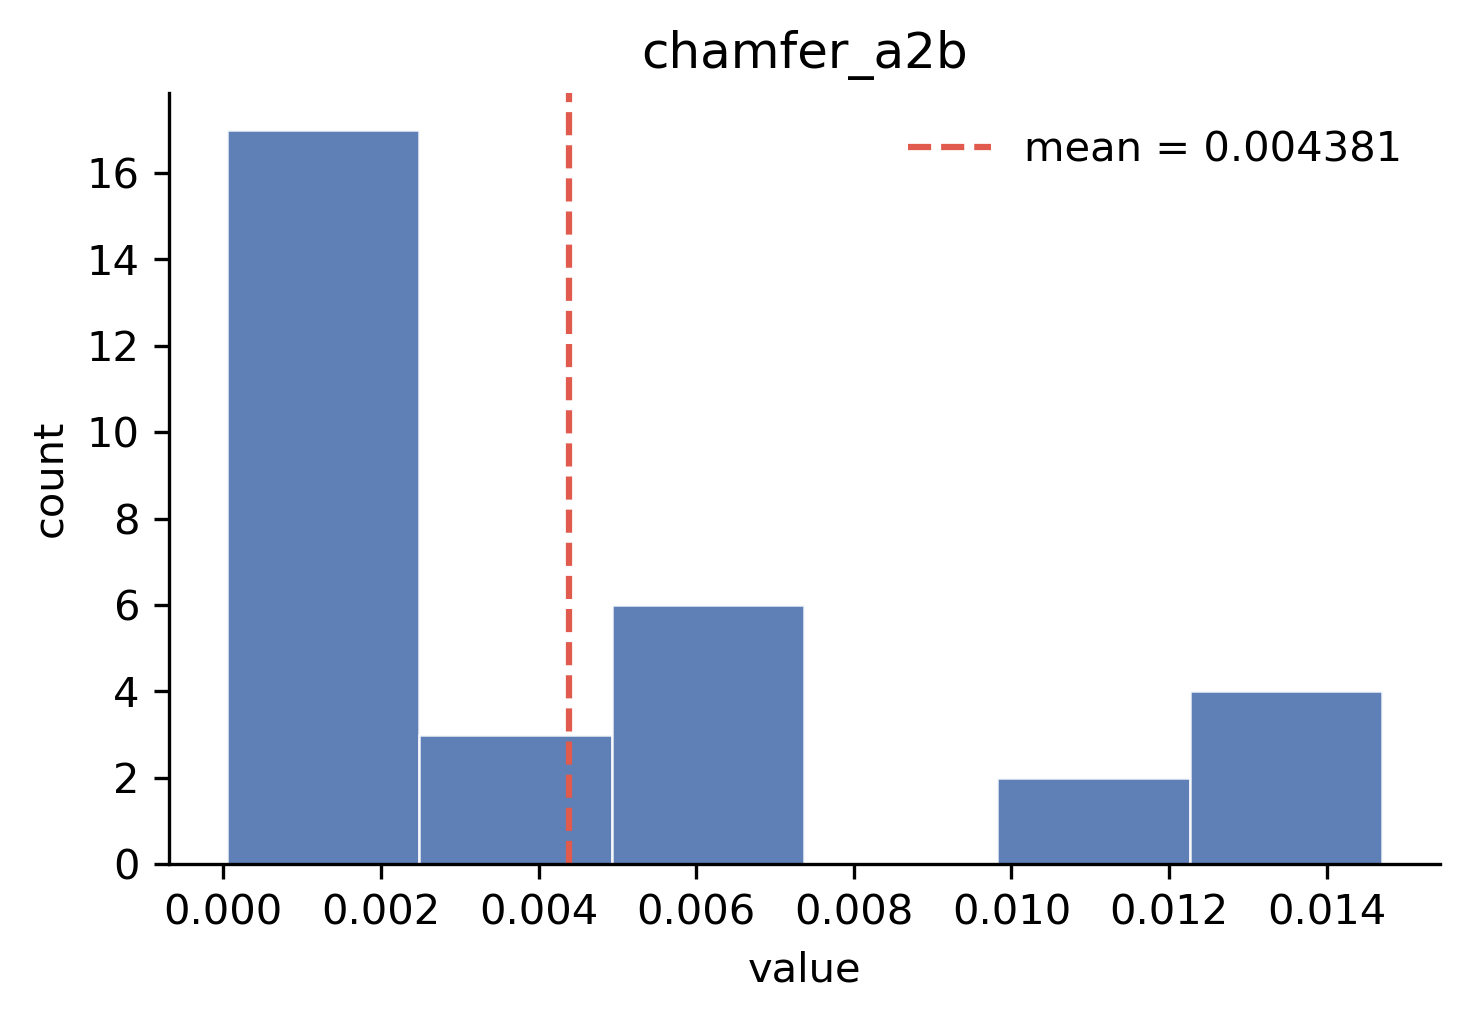

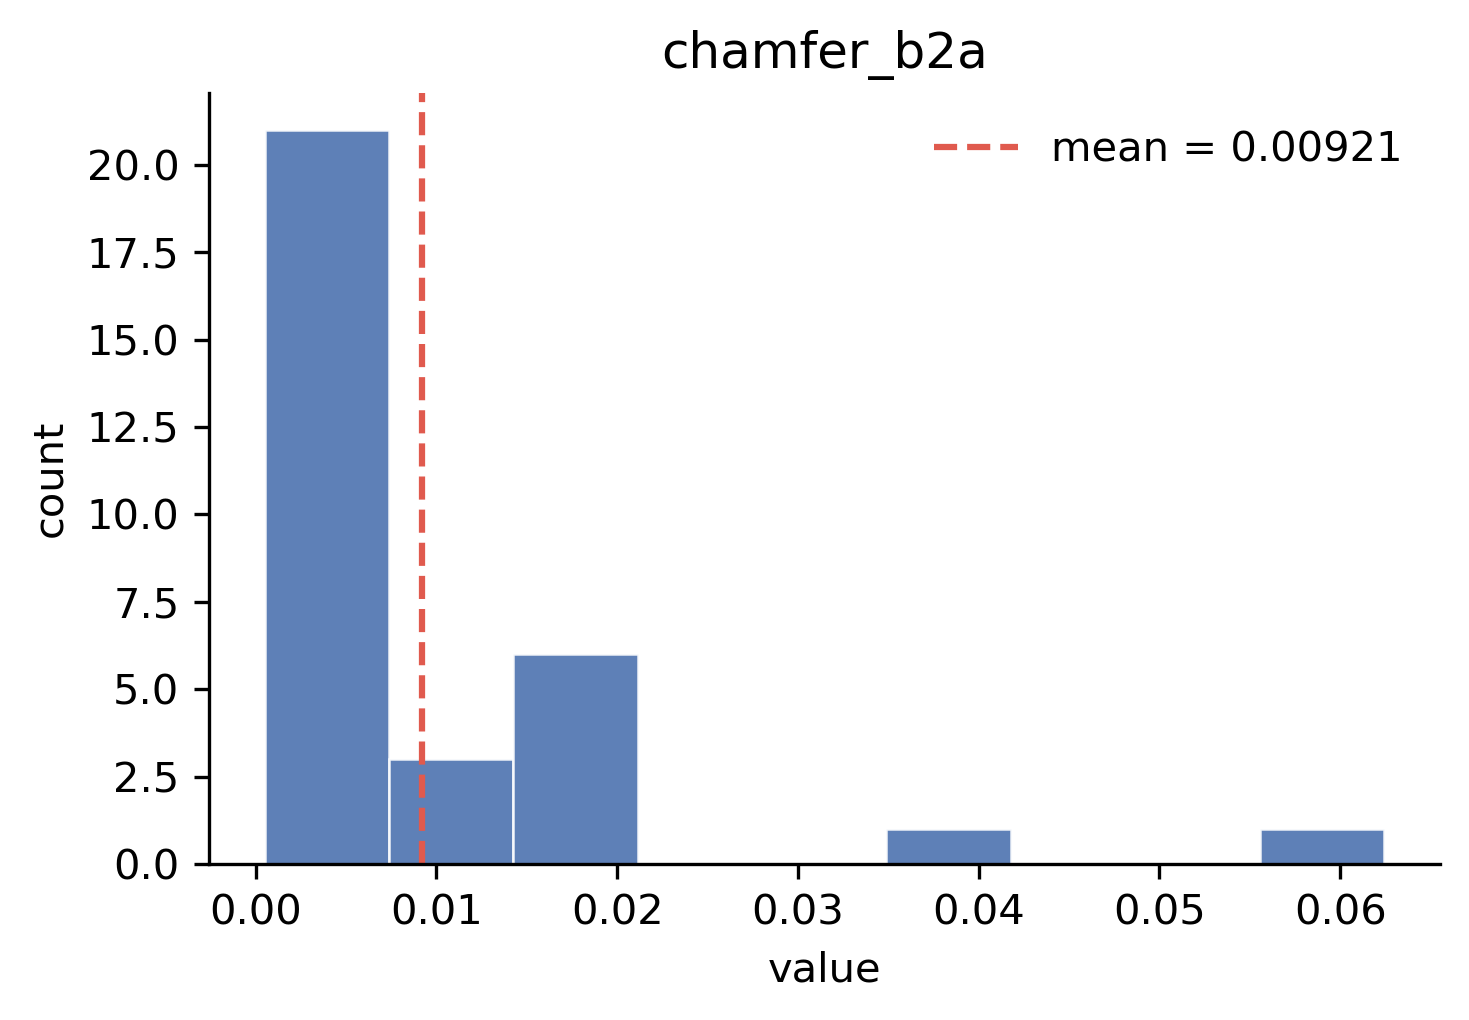

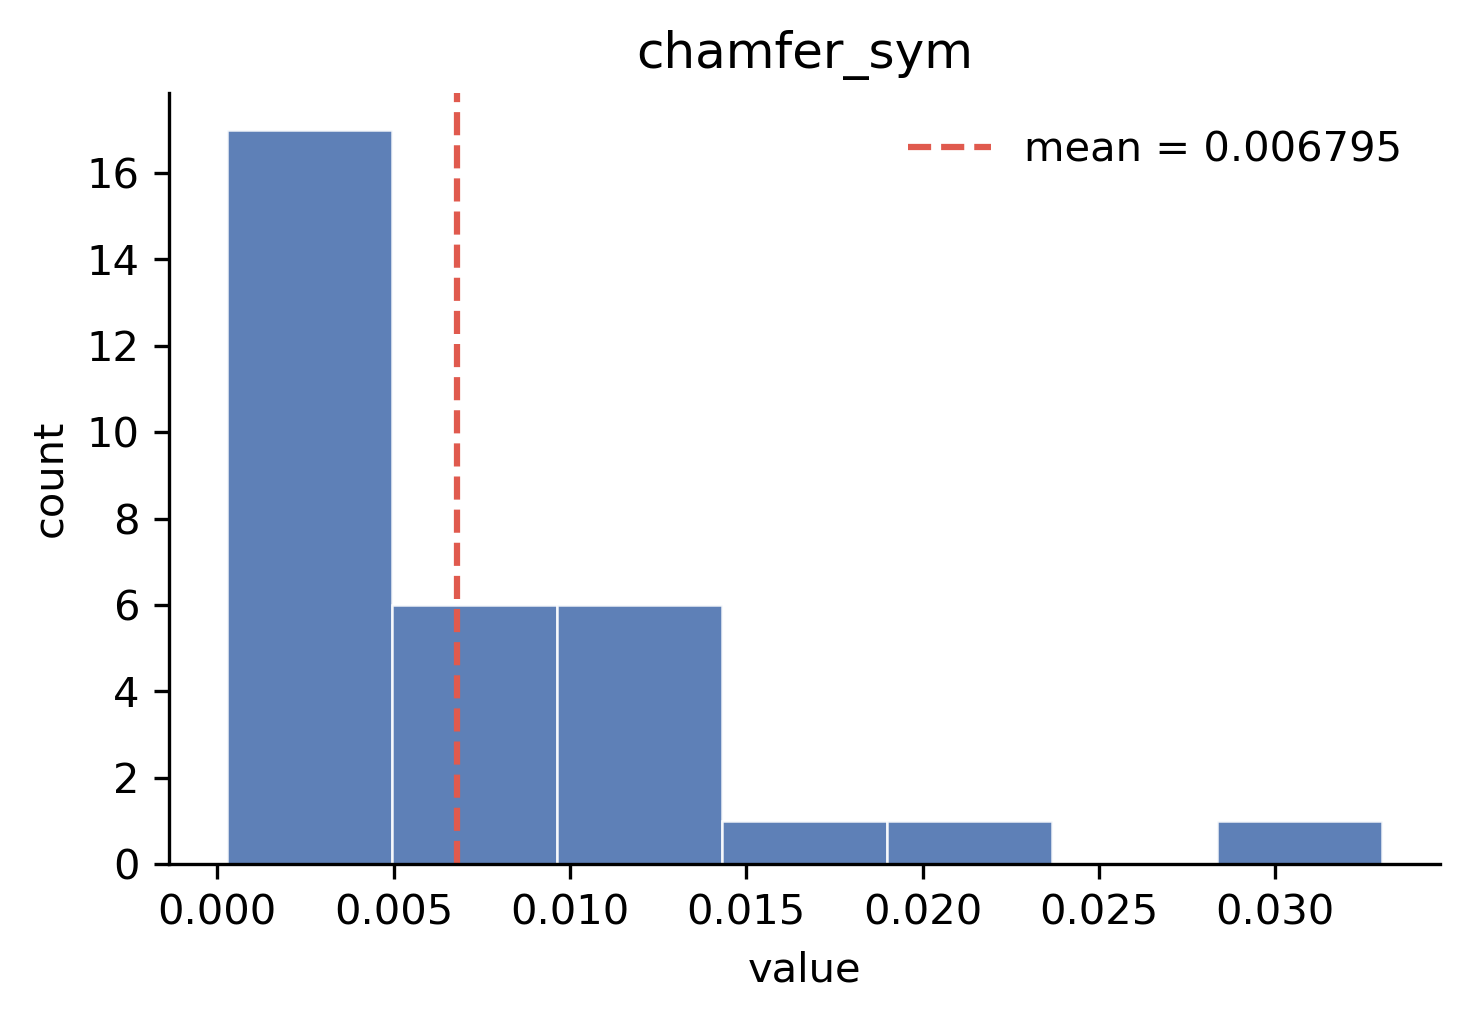

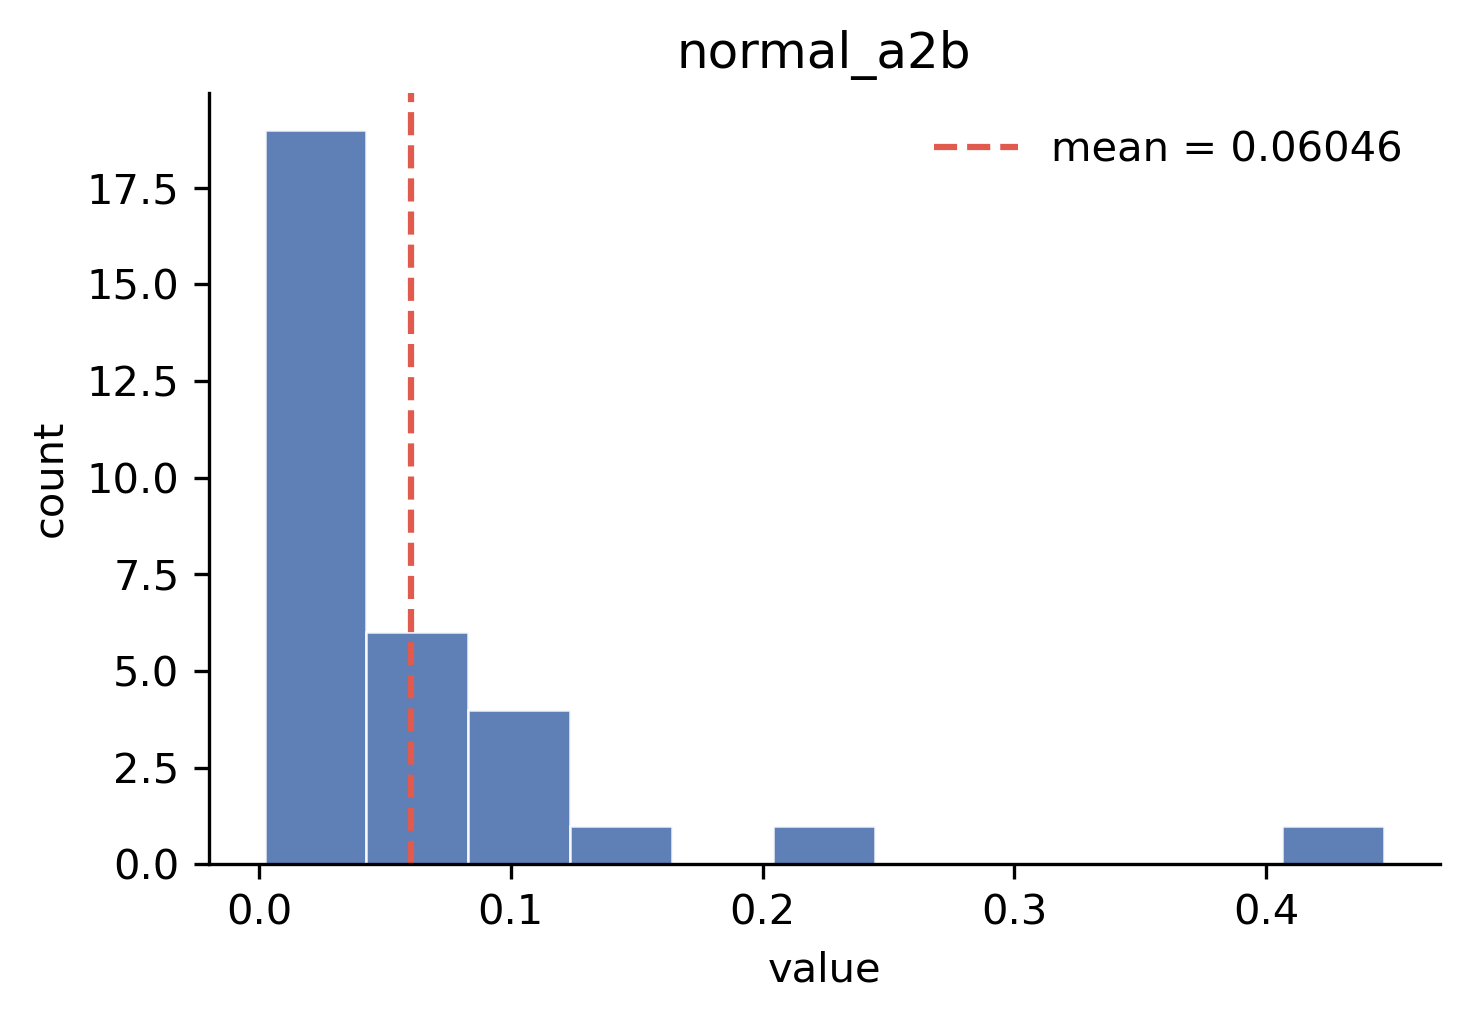

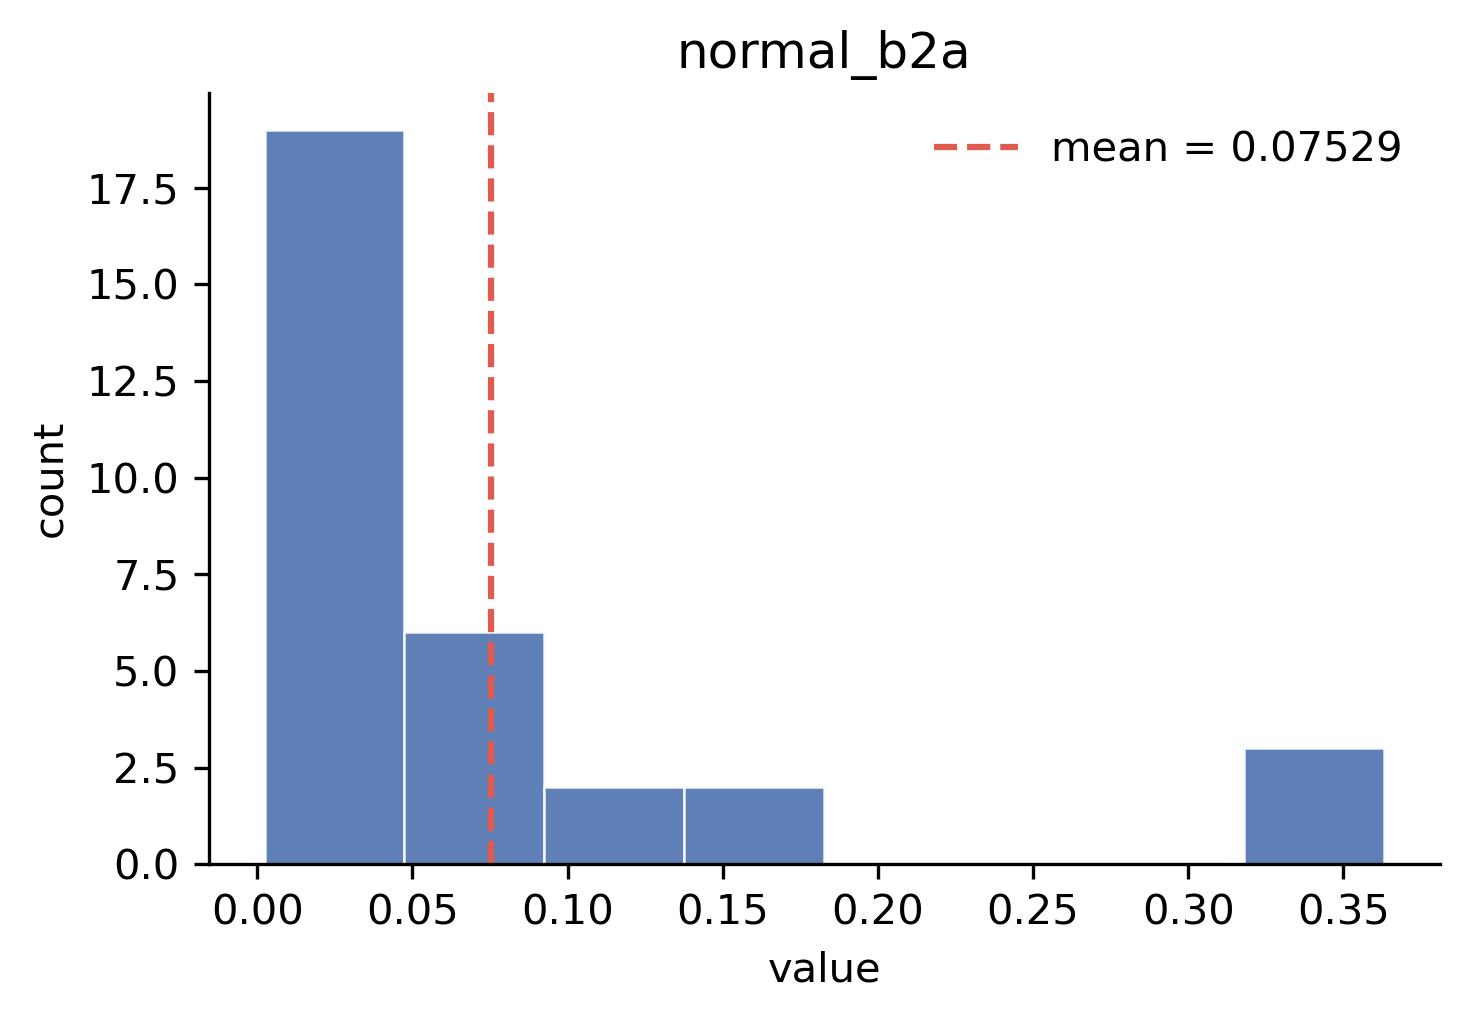

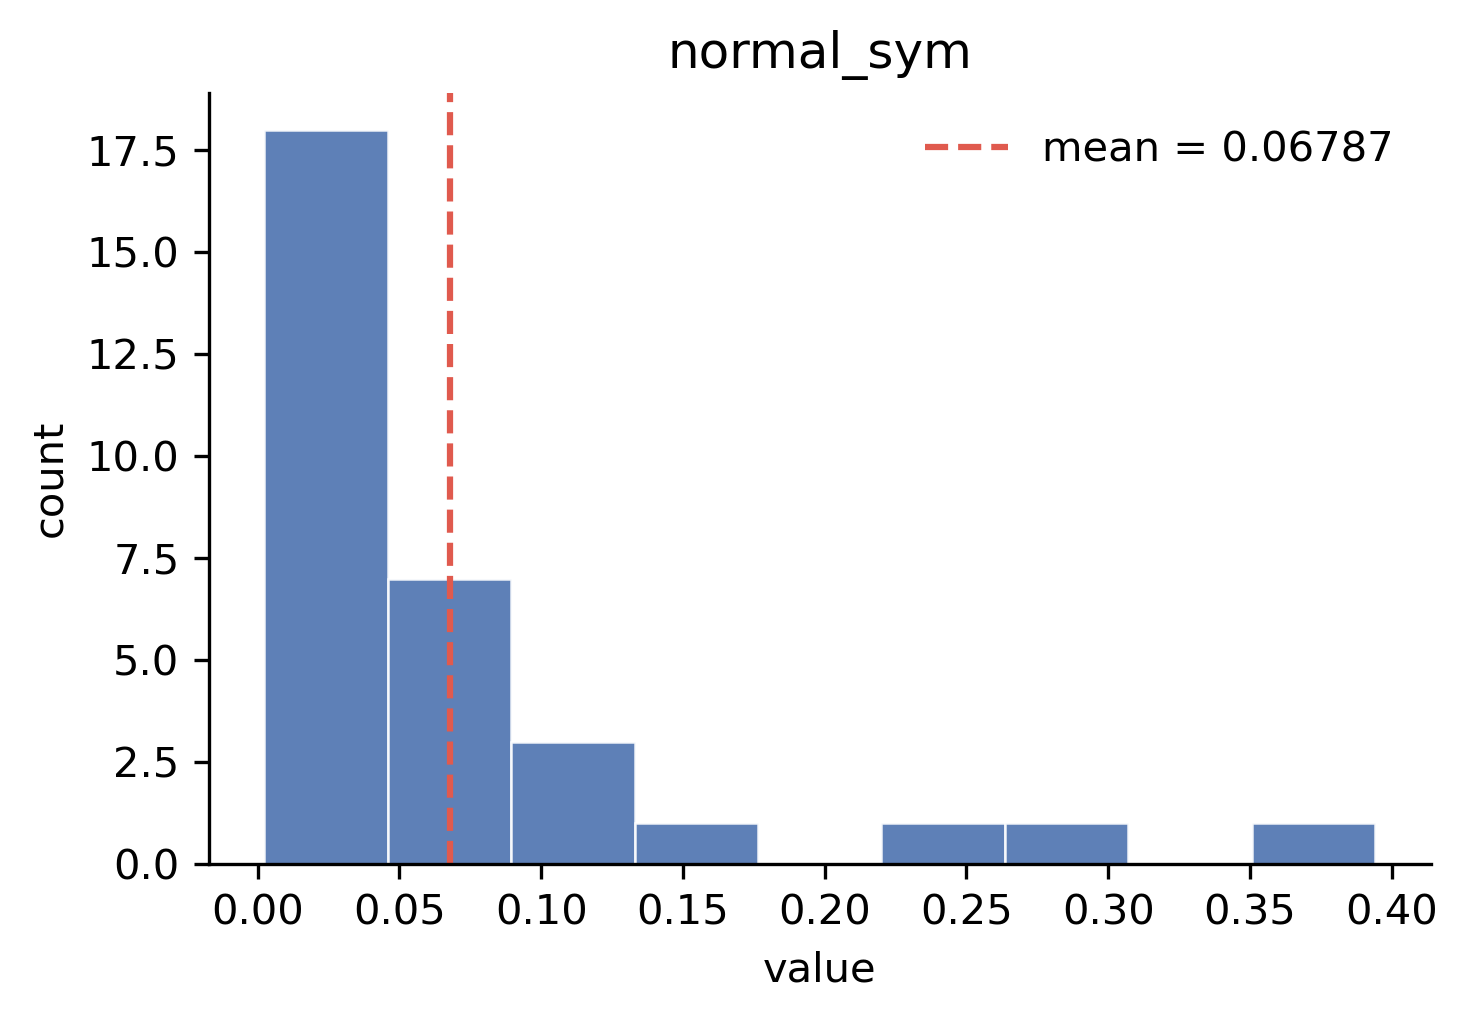

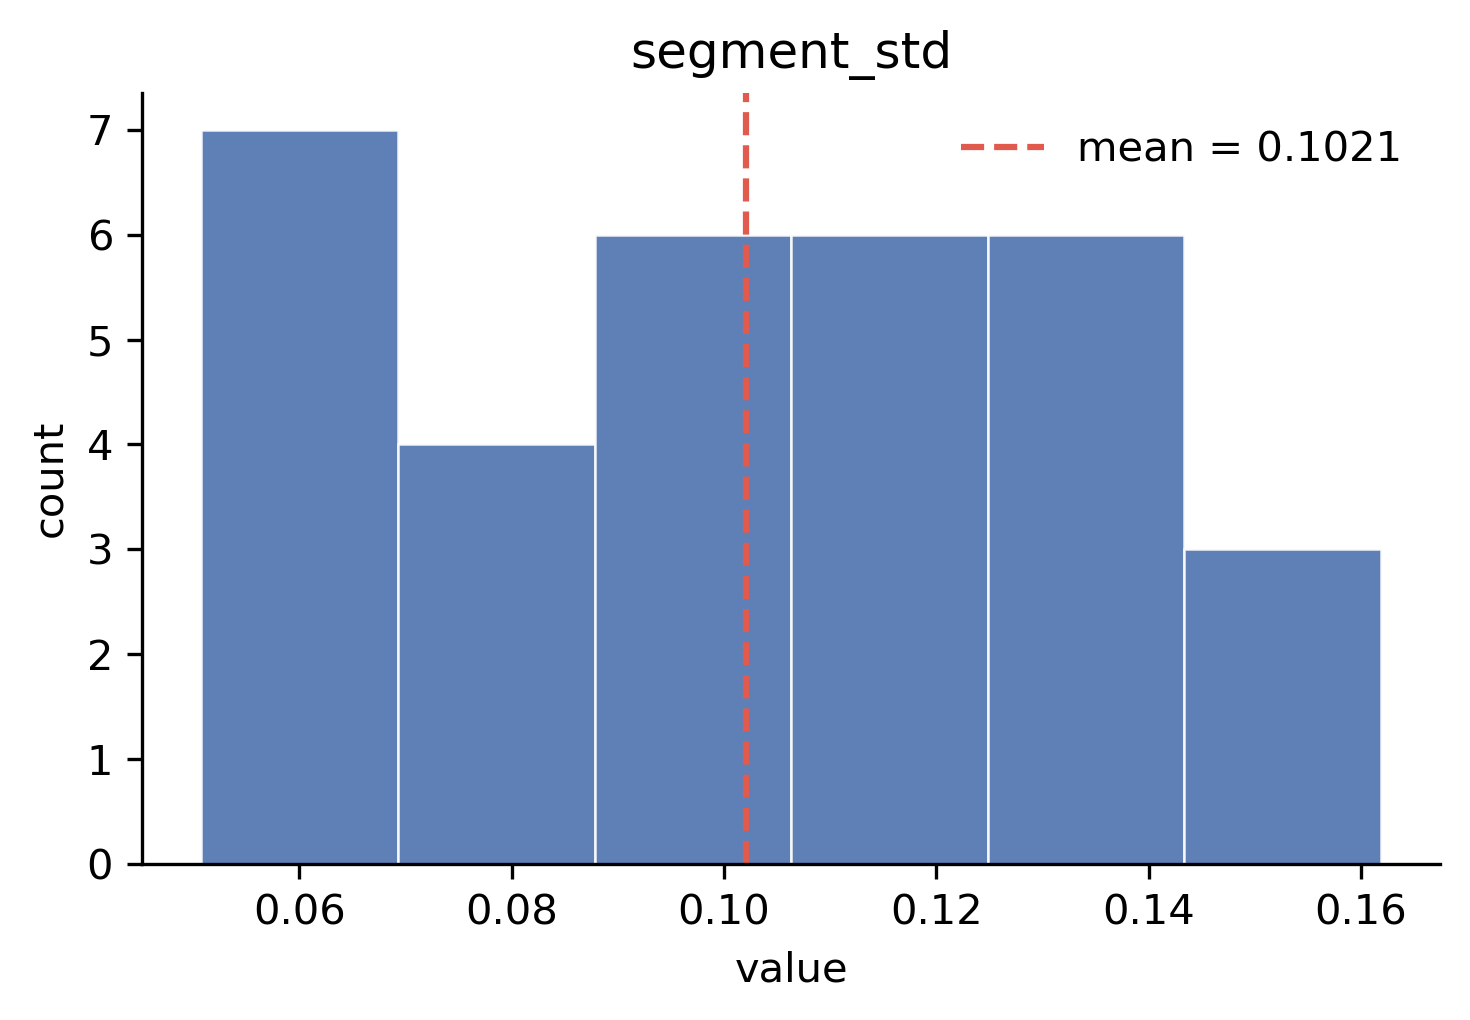

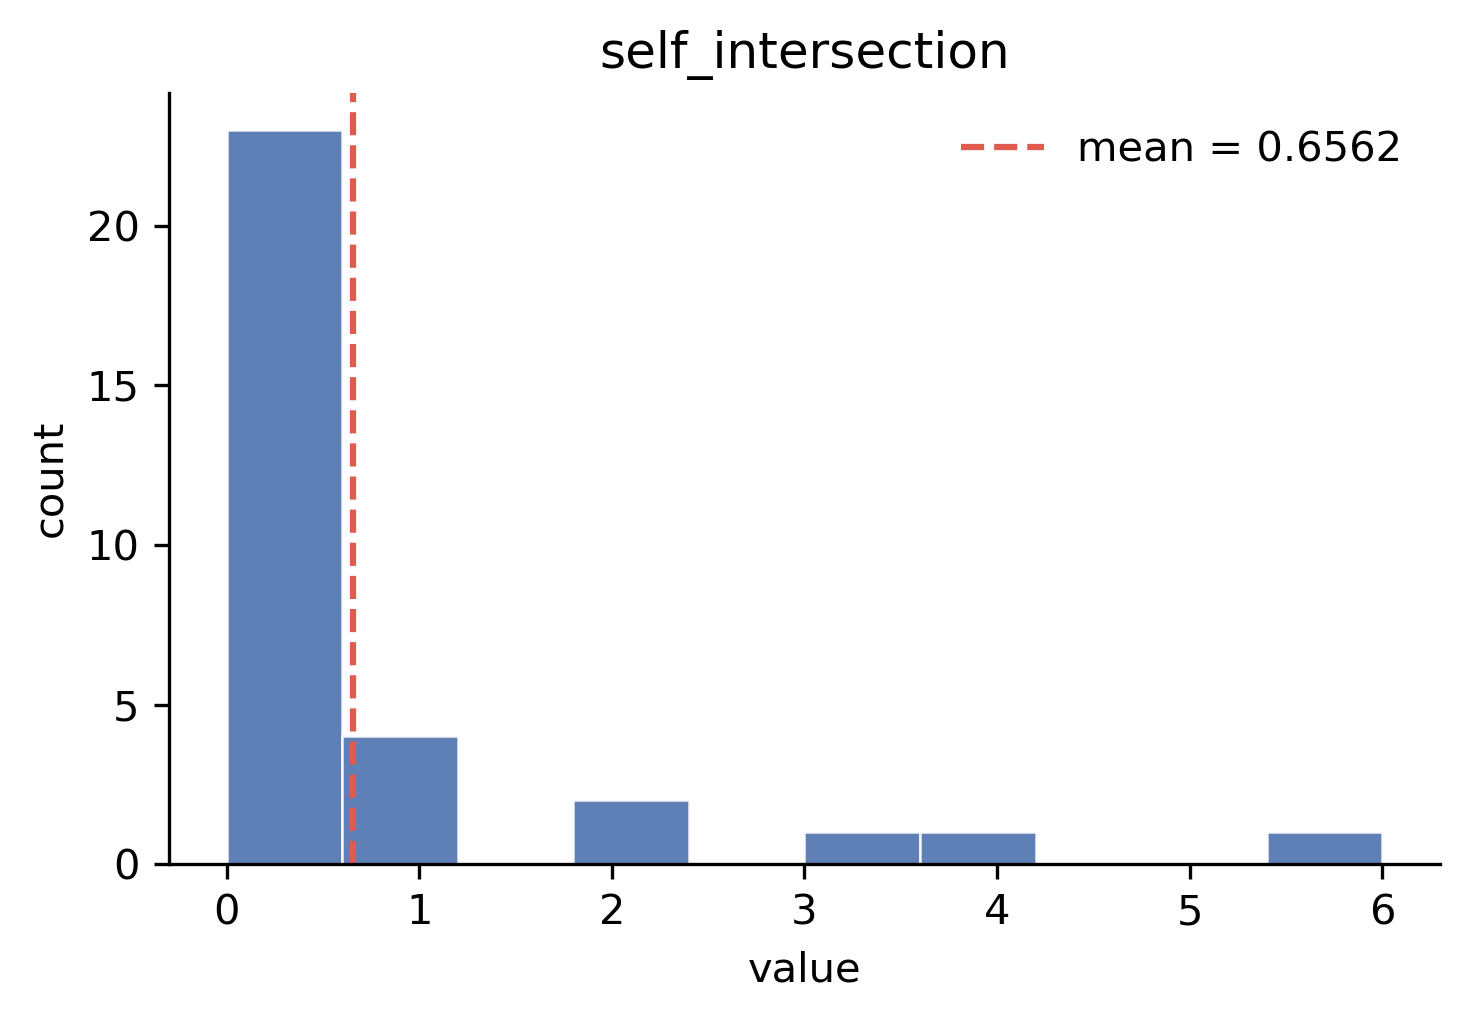

In [10]:
# ── Configure run ───────────────────────────────────────────────────────────
CSV_PATH = Path("../outputs/evaluate_harness/2026-06-01/21-02-24/results.csv")

# Set to a directory path to save PDF figures; leave None to only display.
SAVE_DIR = Path("report") / "figures" / "learned"

df, summary, figures = evaluate_harness_csv(
    CSV_PATH,
    save_dir=SAVE_DIR,
    dpi=DEFAULT_DPI,
    show=True,
)

Loaded 256 rows from /home/deniz/rl-mesh-deformation/outputs/evaluate_harness/2026-06-01/21-04-12/results.csv
run_id: 21-04-12
samples: 32  metrics: 8



,metric,count,mean,std,median,min,max
0,chamfer_a2b,32,0.006254,0.014700,0.001453,0.000185,0.076779
1,chamfer_b2a,32,0.005930,0.010860,0.002201,0.000249,0.044432
2,chamfer_sym,32,0.006092,0.011612,0.001966,0.000244,0.049092
3,normal_a2b,32,0.137209,0.236766,0.060606,0.000889,0.934829
4,normal_b2a,32,0.098479,0.108972,0.067255,0.000914,0.420727
5,normal_sym,32,0.117844,0.159587,0.073220,0.000902,0.631105
6,segment_std,32,0.078726,0.057351,0.064599,0.017636,0.272479
7,self_intersection,32,0.000000,0.000000,0.000000,0.000000,0.000000


Saved report/figures/chamfer/histogram_all_metrics.pdf
Saved report/figures/chamfer/histogram_chamfer_a2b.pdf
Saved report/figures/chamfer/histogram_chamfer_b2a.pdf
Saved report/figures/chamfer/histogram_chamfer_sym.pdf
Saved report/figures/chamfer/histogram_normal_a2b.pdf
Saved report/figures/chamfer/histogram_normal_b2a.pdf
Saved report/figures/chamfer/histogram_normal_sym.pdf
Saved report/figures/chamfer/histogram_segment_std.pdf
Saved report/figures/chamfer/histogram_self_intersection.pdf


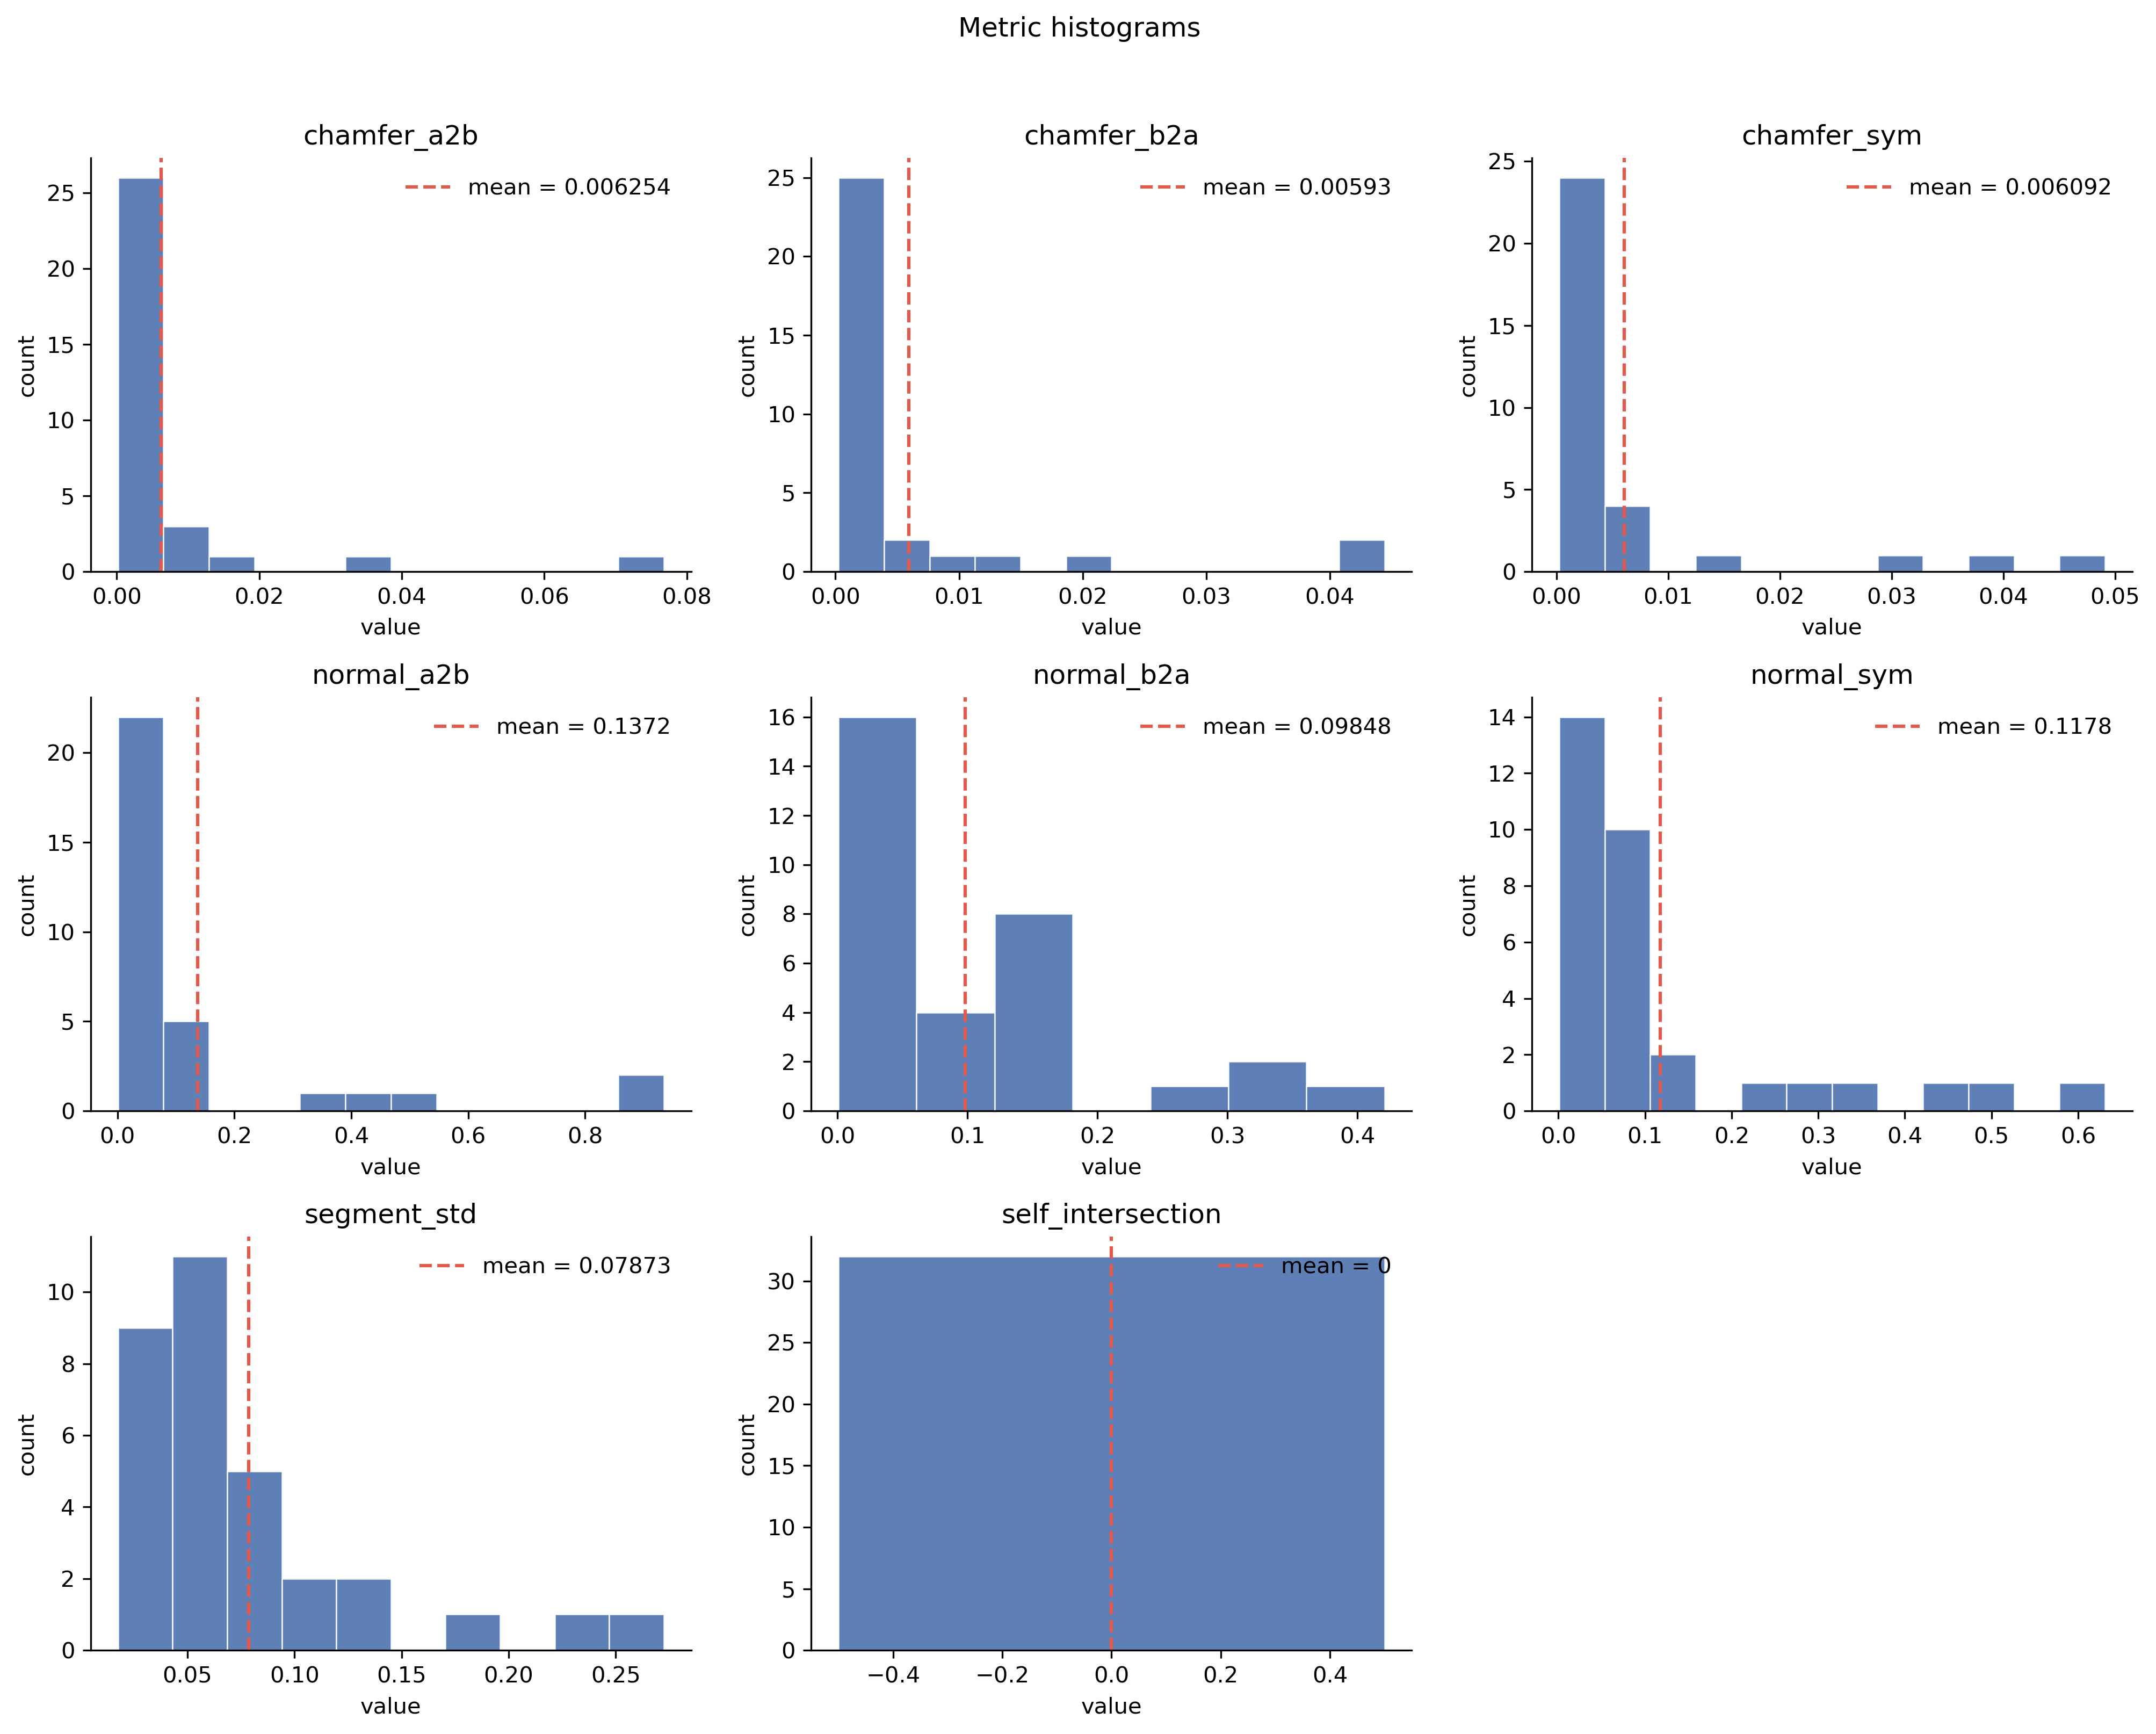

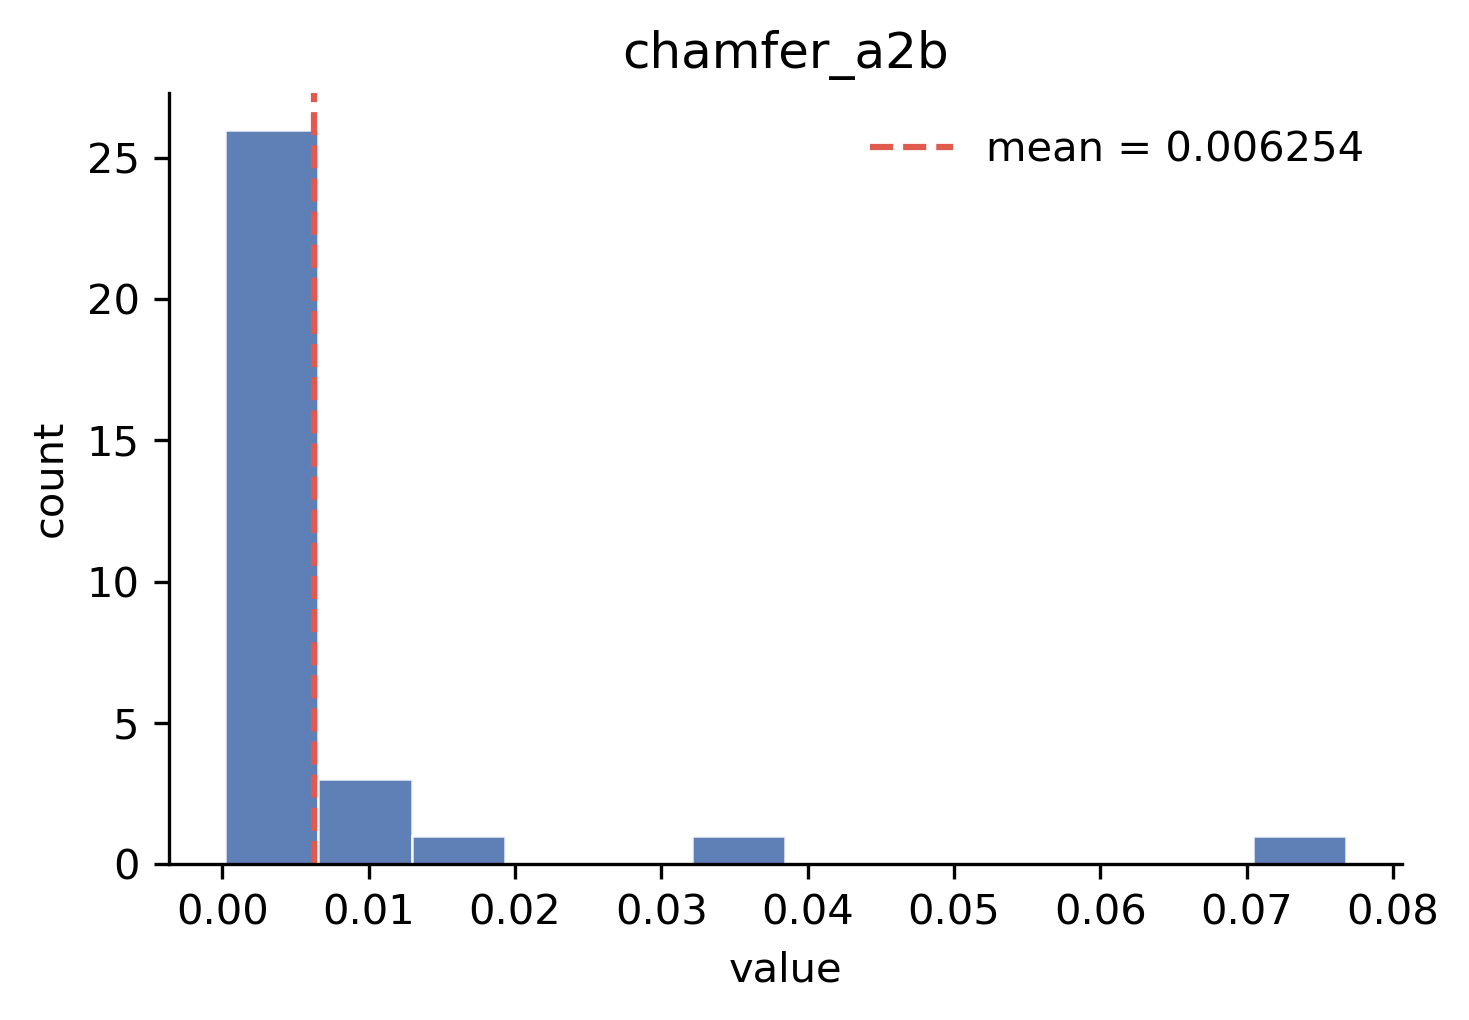

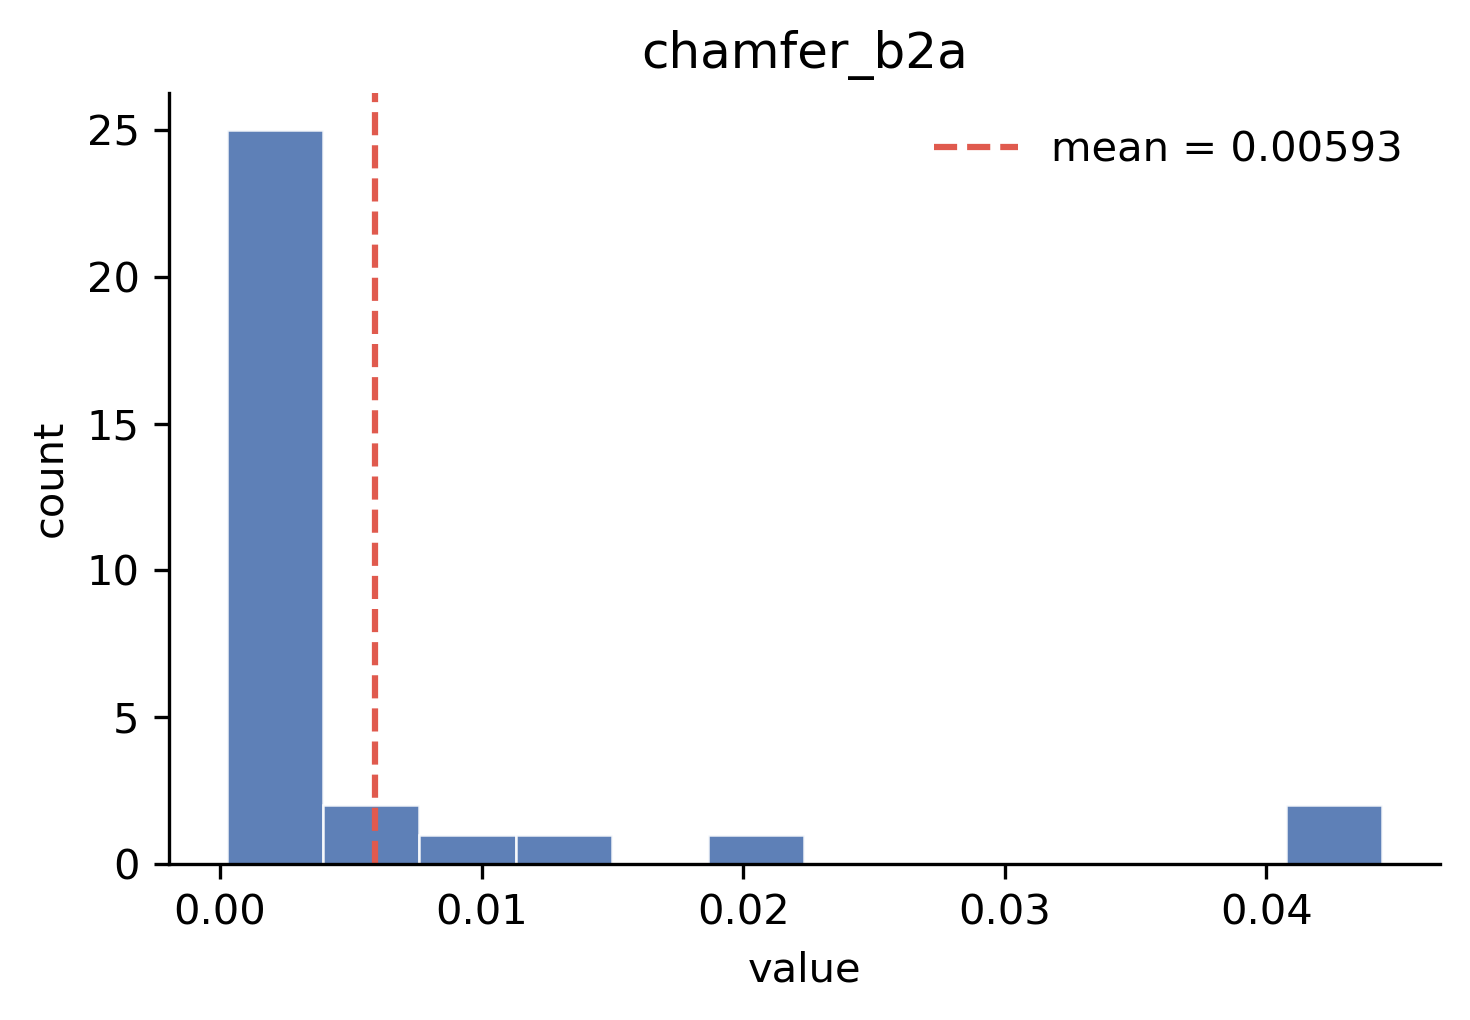

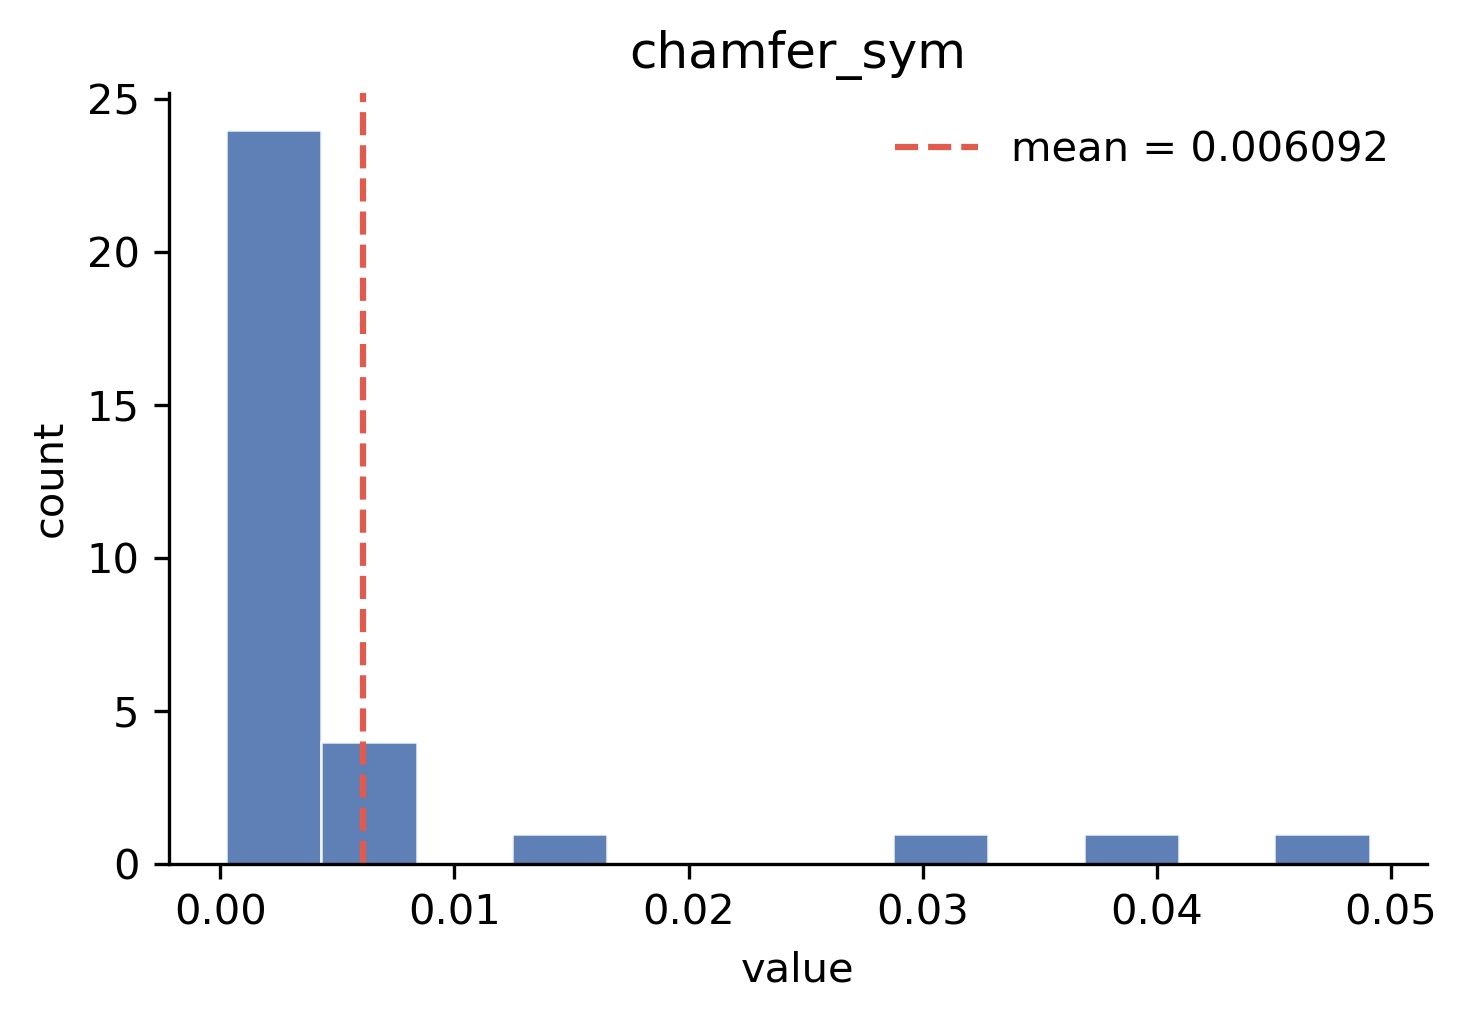

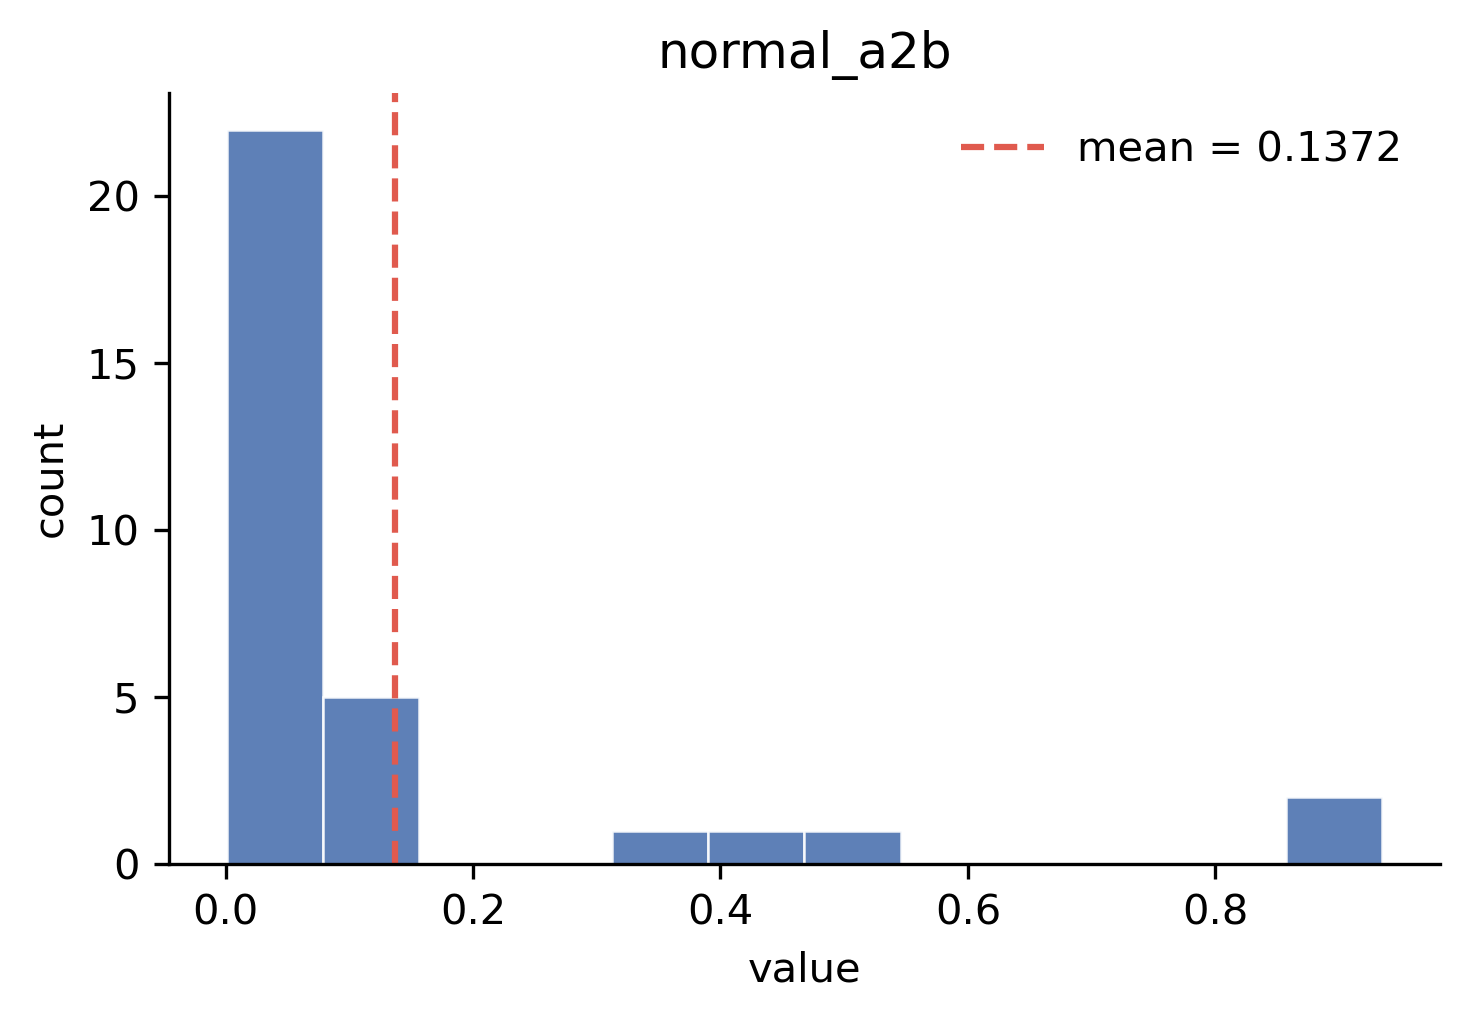

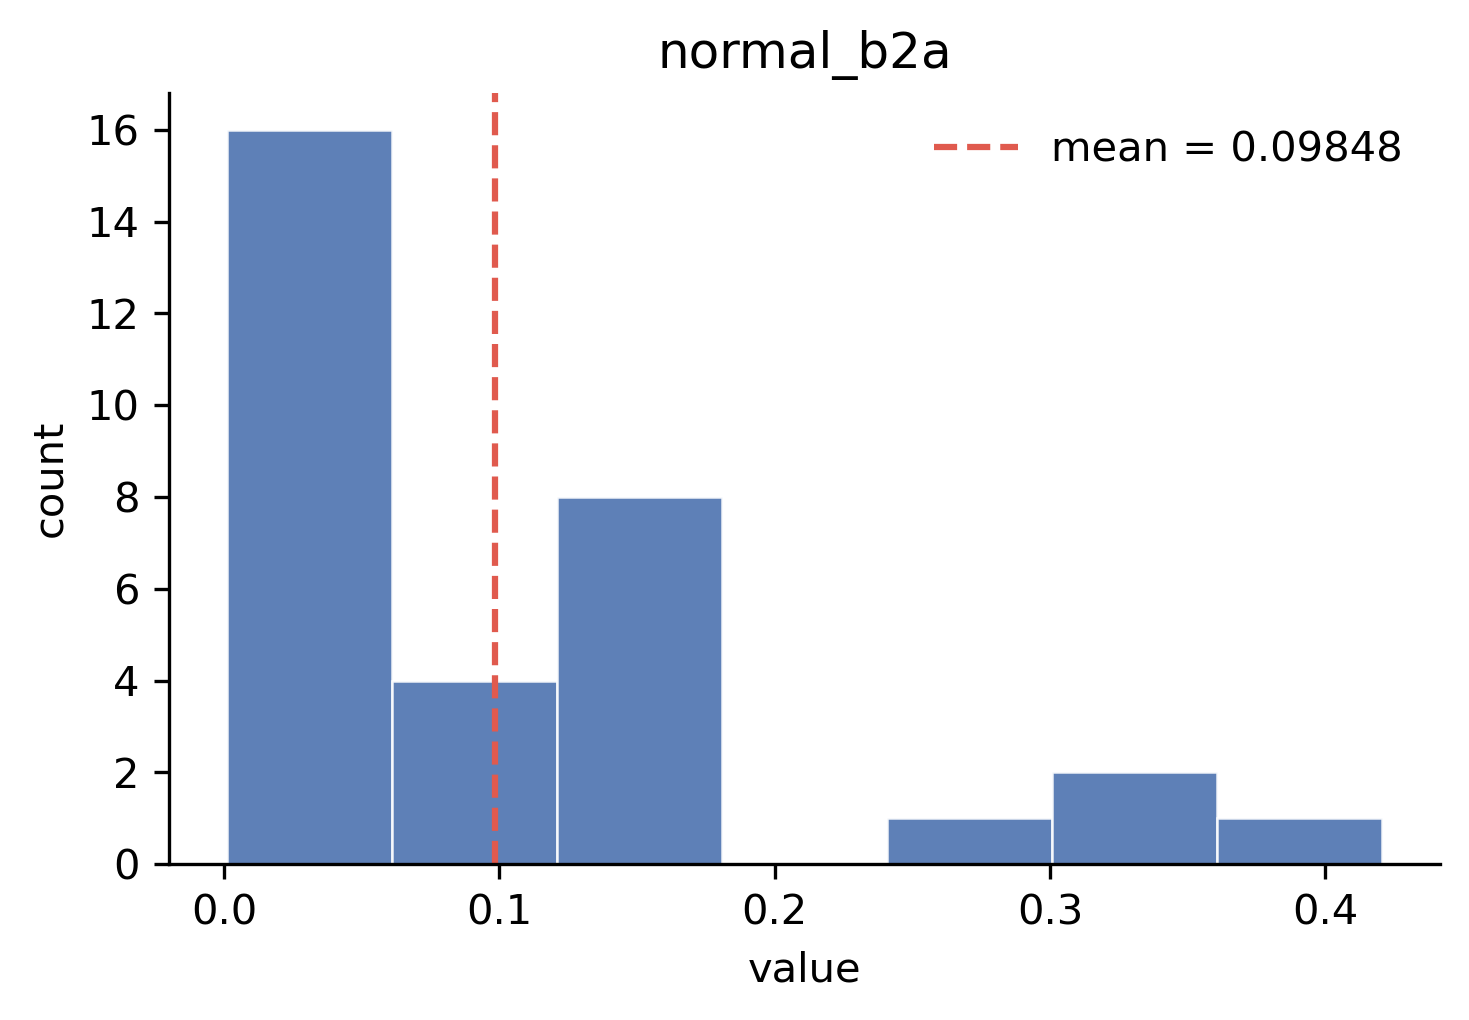

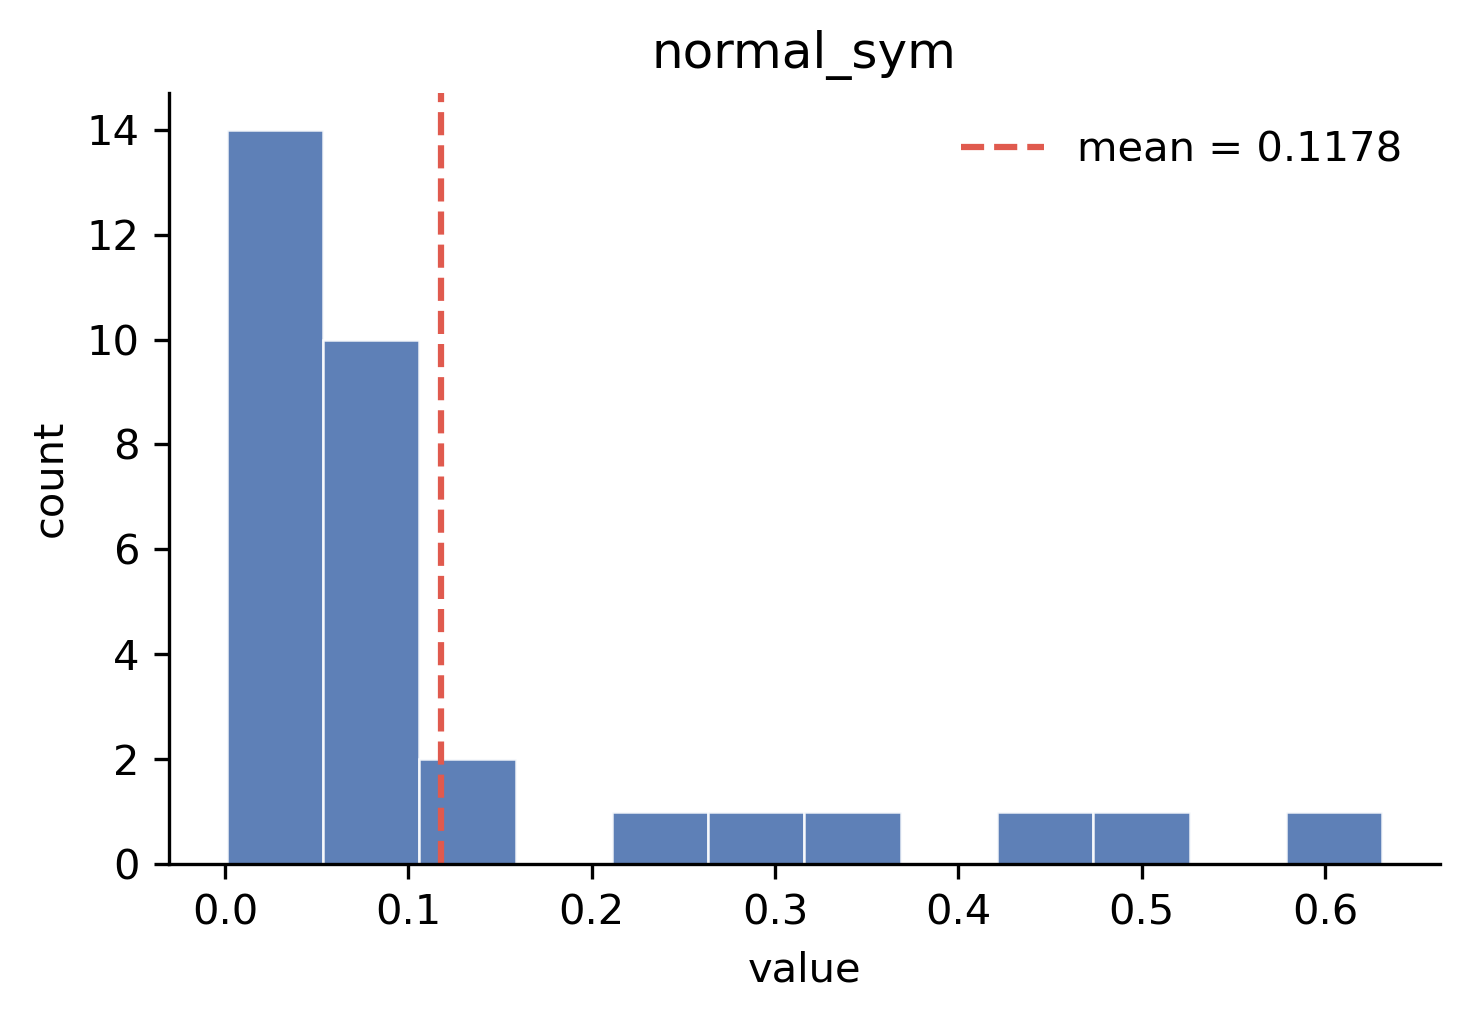

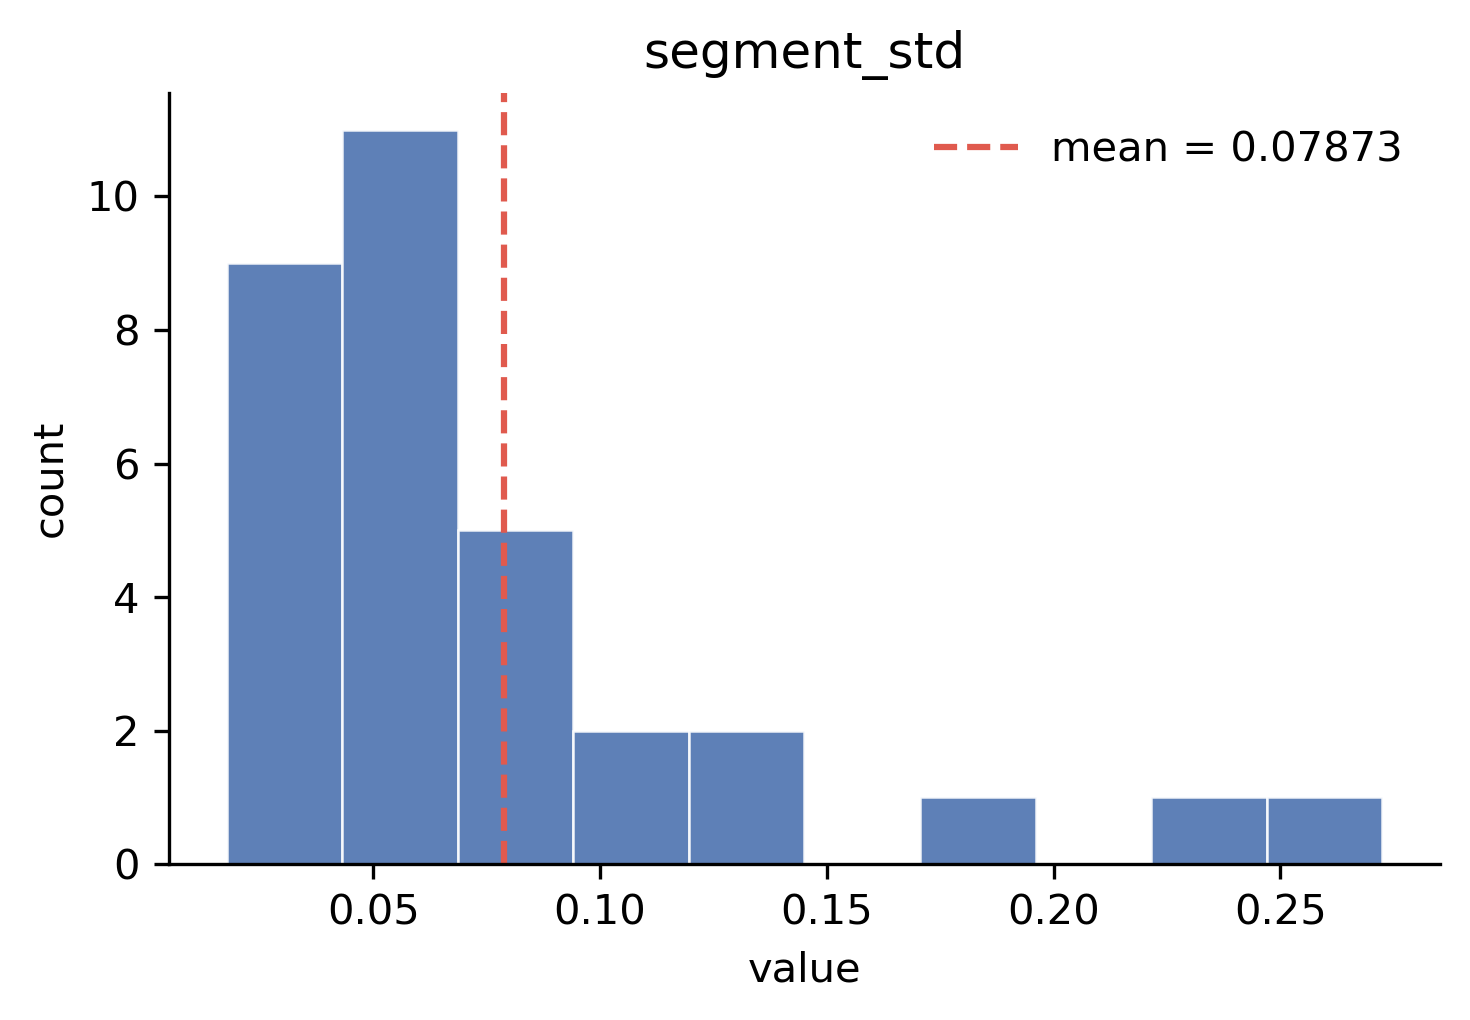

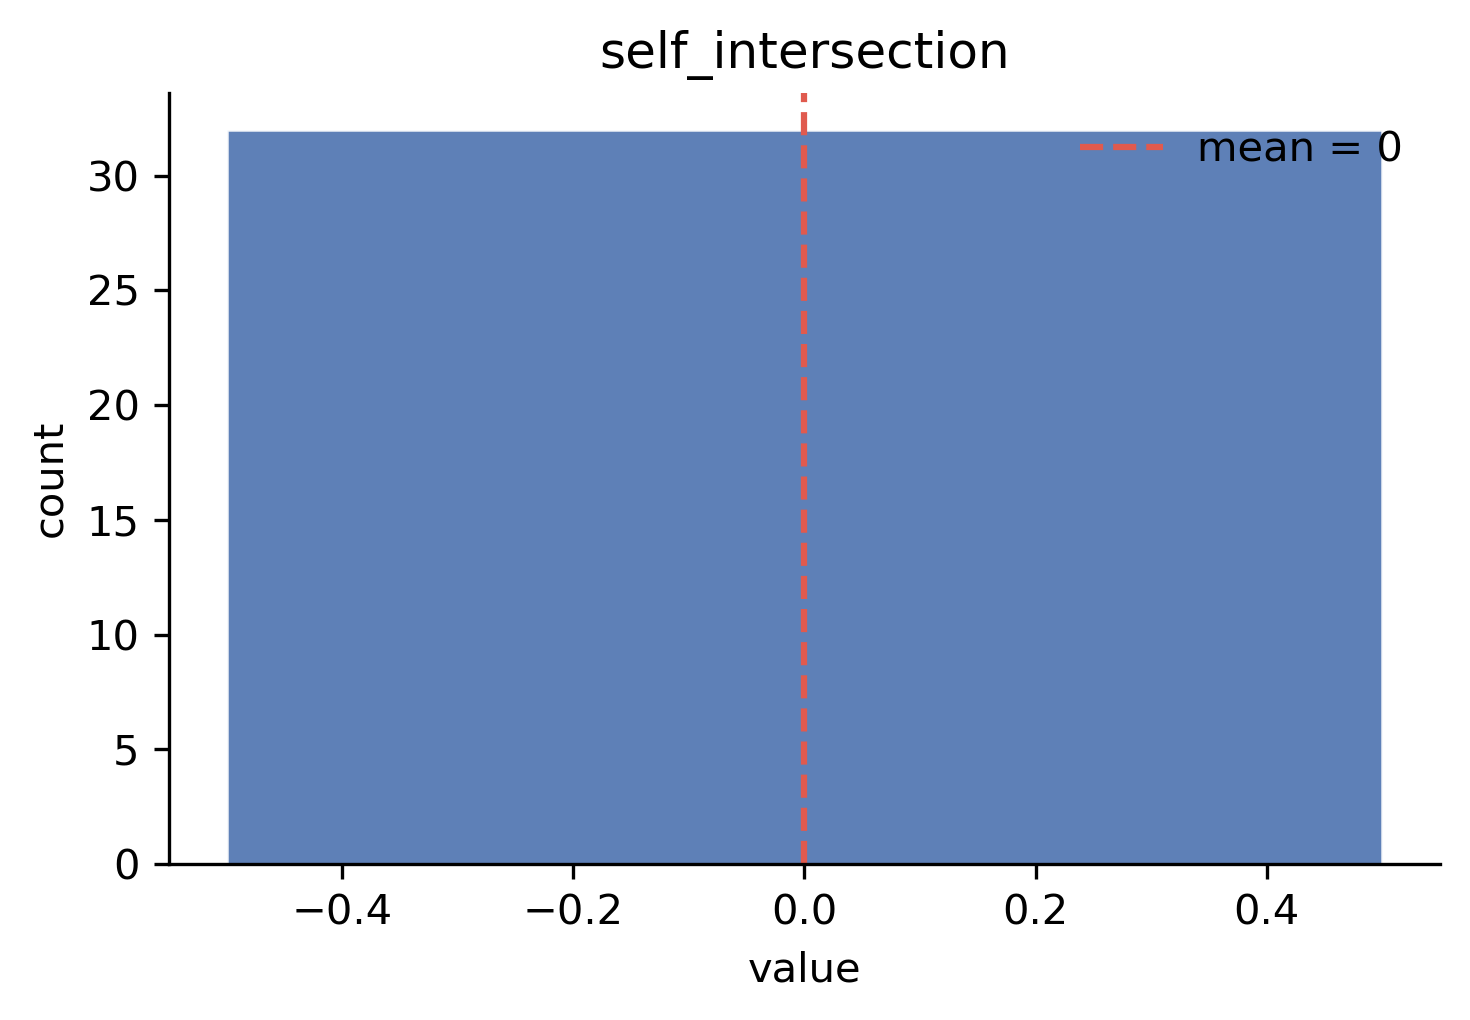

In [11]:
# ── Configure run ───────────────────────────────────────────────────────────
CSV_PATH = Path("../outputs/evaluate_harness/2026-06-01/21-04-12/results.csv")

# Set to a directory path to save PDF figures; leave None to only display.
SAVE_DIR = Path("report") / "figures" / "chamfer"

df, summary, figures = evaluate_harness_csv(
    CSV_PATH,
    save_dir=SAVE_DIR,
    dpi=DEFAULT_DPI,
    show=True,
)